# Multi-asset forecasting with an LSTM

This notebook contains code for training and forecasting 22 stocks from the OMXS30 index
with an LSTM model.

Import data and create the dataloader

In [11]:
import pandas as pd
import deeplay
import importlib
import data.MultiAssetDataset_v3
importlib.reload(data.MultiAssetDataset_v3)
from data.MultiAssetDataset_v3 import MultiAssetSequencedDataset
from torch.utils.data import DataLoader

df = pd.read_csv("data/OMXS22_model_features_raw.csv", index_col = "Date", parse_dates = True)

tickers = df["Ticker"].unique().tolist()
# tickers = ["KINV-B.ST"] #, "SAND.ST"]
ticker_embedding = {ticker: i for i, ticker in enumerate(tickers)}
df["Ticker embedding"] = df["Ticker"].map(ticker_embedding)
print(df.head())
features = ["Close"] #, "Ticker embedding" # , "Volume", "SMA20", "RSI14"]
target_col = "Close"
window   = 100
window_step_length = 6
horizon  = [i for i in range(1, 21)]


train_stop = pd.Timestamp("2018-01-01")
val_stop   = pd.Timestamp("2023-07-28")

df_train = df[df.index < train_stop].copy()

df_val   = df[(df.index >= train_stop) & (df.index < val_stop)].copy()
df_test  = df[df.index >= val_stop].copy()
df_val_test = df[df.index >= train_stop].copy()


ds_train = MultiAssetSequencedDataset(df_train, tickers, features, target_col, False, window, window_step_length=50, horizon=horizon, num_permutations=50)
ds_train.create()
ds_val   = MultiAssetSequencedDataset(df_val,   tickers, features, target_col, False, window, window_step_length=1, horizon=horizon)
ds_val.create()
ds_test  = MultiAssetSequencedDataset(df_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_test.create()
ds_val_test = MultiAssetSequencedDataset(df_val_test,  tickers, features, target_col, False, window, window_step_length=max(horizon), horizon=horizon)
ds_val_test.create()


train_loader = DataLoader(ds_train, batch_size=32)
val_loader   = DataLoader(ds_val,   batch_size=32)
test_loader  = DataLoader(ds_test,  batch_size=32)

print(f"Train set length: {len(ds_train)}")
print(f"Train set input shape: {ds_train[0][0].shape}")
print(f"Train set target shape: {ds_train[0][1].shape}")
print(f"Val set length: {len(ds_val)}")
print(f"Dataset length: {len(ds_train) + len(ds_val) + len(ds_test)}")

print(f"Test set number of days: {len(df_test.index.unique())}")
print(f"Test set number of sequences: {len(ds_test)}")

               Ticker       Close  ...  BRENT_ret  Ticker embedding
Date                               ...                             
2000-01-04  ASSA-B.ST   23.572845  ...   0.017296                 0
2000-01-04  ATCO-A.ST    3.945862  ...   0.017296                 1
2000-01-04  ATCO-B.ST    3.067595  ...   0.017296                 2
2000-01-04     AZN.ST  279.147308  ...   0.017296                 3
2000-01-04  ELUX-B.ST   31.041374  ...   0.017296                 4

[5 rows x 14 columns]
Train set length: 4500
Train set input shape: torch.Size([100, 22])
Train set target shape: torch.Size([440])
Val set length: 1280
Dataset length: 5797
Test set number of days: 440
Test set number of sequences: 17


In [14]:
print(ds_val.y_mean.mean(), ds_test.y_mean.mean())

156.06248417307162 220.05015202884366


In [15]:
sequence_dates = ds_test.sequence_dates.copy()
target_dates = ds_test.target_dates.copy()
print(f"Test set sequence dates: {sequence_dates}")
print(f"Test set target dates: {target_dates}")
print(f"len(sequence_dates): {len(sequence_dates)}")

Test set sequence dates: [Timestamp('2023-12-14 00:00:00'), Timestamp('2024-01-16 00:00:00'), Timestamp('2024-02-13 00:00:00'), Timestamp('2024-03-12 00:00:00'), Timestamp('2024-04-11 00:00:00'), Timestamp('2024-05-13 00:00:00'), Timestamp('2024-06-11 00:00:00'), Timestamp('2024-07-10 00:00:00'), Timestamp('2024-08-07 00:00:00'), Timestamp('2024-09-04 00:00:00'), Timestamp('2024-10-02 00:00:00'), Timestamp('2024-10-30 00:00:00'), Timestamp('2024-11-27 00:00:00'), Timestamp('2024-12-30 00:00:00'), Timestamp('2025-01-30 00:00:00'), Timestamp('2025-02-27 00:00:00'), Timestamp('2025-03-27 00:00:00')]
Test set target dates: [Timestamp('2024-01-16 00:00:00'), Timestamp('2024-02-13 00:00:00'), Timestamp('2024-03-12 00:00:00'), Timestamp('2024-04-11 00:00:00'), Timestamp('2024-05-13 00:00:00'), Timestamp('2024-06-11 00:00:00'), Timestamp('2024-07-10 00:00:00'), Timestamp('2024-08-07 00:00:00'), Timestamp('2024-09-04 00:00:00'), Timestamp('2024-10-02 00:00:00'), Timestamp('2024-10-30 00:00:00')

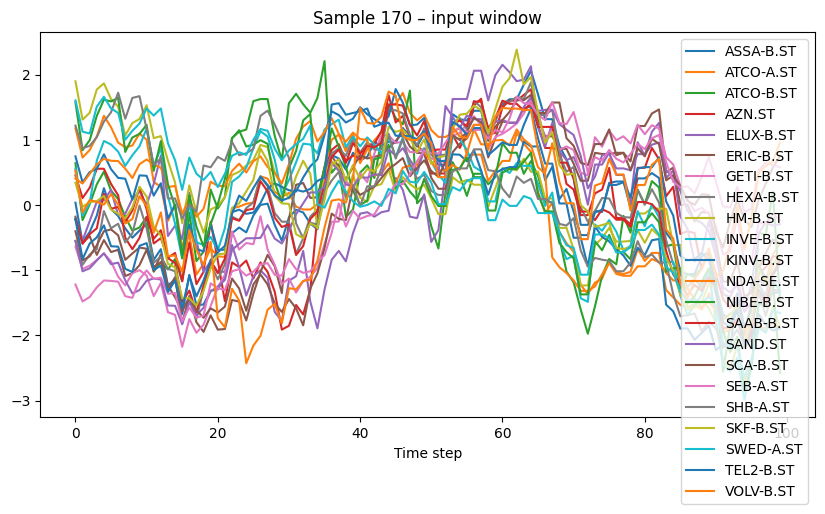

In [38]:
import matplotlib.pyplot as plt

def plot_sample_from_dataset(ds, idx=0, tickers=None, features=None):
    """
    Visualiserar en sample från ett MultiAssetSequencedDataset.

    Parametrar:
        ds       – dataset-instans (t.ex. ds_train)
        idx      – vilket sample (default: 0)
        tickers  – lista med ticker-namn (om du vill annotera)
        features – lista med feature-namn (för att tolka A*F)
    """
    x, y = ds[idx]  # x: (W, A*F), y: (A,) eller (A, H)

    W = x.shape[0]
    AF = x.shape[1]
    A = len(ds.tickers)
    F = len(ds.features)

    # Återskapa till (W, A, F)
    x = x.view(W, A, F).numpy()
    if F > 1:
        fig, axs = plt.subplots(F, 1, figsize=(10, 2.5 * F), sharex=True)

        for f in range(F):
            ax = axs[f] if F > 1 else axs
            for a in range(A):
                label = tickers[a] if tickers else f"Asset {a}"
                ax.plot(range(W), x[:, a, f], label=label)
            feat_name = features[f] if features else f"Feature {f}"
            ax.set_title(f"Feature {f}: {feat_name}")
            ax.legend()
        
        plt.suptitle(f"Sample {idx} – input window")
        plt.xlabel("Time step")
        #plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(10, 5))
        for a in range(A):
            label = tickers[a] if tickers else f"Asset {a}"
            plt.plot(range(W), x[:, a, 0], label=label)
        plt.title(f"Sample {idx} – input window")
        plt.xlabel("Time step")
        plt.legend()
        plt.show()

plot_sample_from_dataset(ds_train, idx=170, tickers=tickers, features=features)


In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from multi_asset_models.MultiAssetLSTM import MultiAssetLSTM
from train.Trainer import Trainer

model = MultiAssetLSTM(
    n_assets=len(tickers),
    n_features=len(features),
    hidden_size=132,
    num_layers=2,
    dropout=0.2,
    horizon=horizon
)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


num_epochs   = 50
patience     = num_epochs
save_path    = "best_multiasset_lstm.pt"

trainer = Trainer(model, optimizer, criterion)
history = trainer.fit(
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = num_epochs,
    patience     = patience,
    save_path    = save_path
)

model.load_state_dict(torch.load(save_path))
test_loss = trainer.eval_epoch(test_loader)
print(f"Test loss: {test_loss:.4f}")

Epoch 1/50 - train_loss: 0.9977, val_loss: 0.9082
Epoch 2/50 - train_loss: 0.7902, val_loss: 0.8705
Epoch 3/50 - train_loss: 0.7690, val_loss: 0.8593
Epoch 4/50 - train_loss: 0.7595, val_loss: 0.8542
Epoch 5/50 - train_loss: 0.7520, val_loss: 0.8527
Epoch 6/50 - train_loss: 0.7462, val_loss: 0.8499
Epoch 7/50 - train_loss: 0.7392, val_loss: 0.8519
Epoch 8/50 - train_loss: 0.7342, val_loss: 0.8541
Epoch 9/50 - train_loss: 0.7273, val_loss: 0.8529
Epoch 10/50 - train_loss: 0.7224, val_loss: 0.8571
Epoch 11/50 - train_loss: 0.7182, val_loss: 0.8598
Epoch 12/50 - train_loss: 0.7115, val_loss: 0.8585
Epoch 13/50 - train_loss: 0.7061, val_loss: 0.8655
Epoch 14/50 - train_loss: 0.7016, val_loss: 0.8636
Epoch 15/50 - train_loss: 0.6956, val_loss: 0.8653
Epoch 16/50 - train_loss: 0.6896, val_loss: 0.8684
Epoch 17/50 - train_loss: 0.6818, val_loss: 0.8675
Epoch 18/50 - train_loss: 0.6760, val_loss: 0.8763
Epoch 19/50 - train_loss: 0.6710, val_loss: 0.8805
Epoch 20/50 - train_loss: 0.6652, val_lo

Naive MAE: nan


C:\Users\peogr\AppData\Local\Temp\ipykernel_31692\3718954263.py:12: RuntimeWarning: Mean of empty slice.
  naive_mae = naive_errors.mean()
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


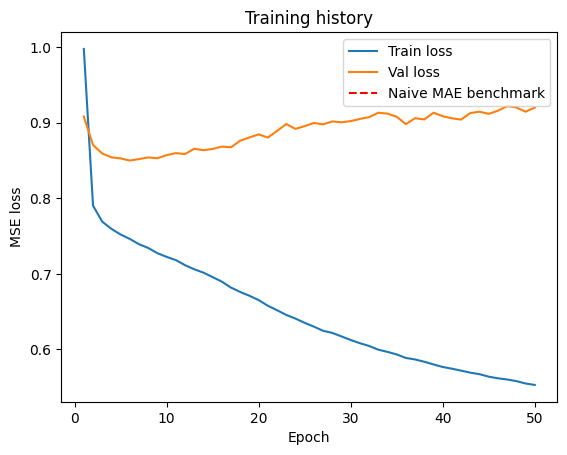

In [40]:
import numpy as np
import matplotlib.pyplot as plt

ys = []
for _, y in DataLoader(ds_test, batch_size=128):
    ys.append(y)
ys = torch.cat(ys, dim=0).numpy()
if ys.ndim == 3:
    ys = ys[:, :, 0]

naive_errors = np.abs(ys[max(horizon):] - ys[:-max(horizon)])
naive_mae = naive_errors.mean()

print(f"Naive MAE: {naive_mae:.4f}")

epochs = np.arange(1, len(history['train_loss']) + 1)
plt.figure()
plt.plot(epochs, history['train_loss'], label='Train loss')
if 'val_loss' in history:
    plt.plot(epochs, history['val_loss'], label='Val loss')
plt.axhline(y=naive_mae, color='r', linestyle='--', label='Naive MAE benchmark')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training history')
plt.legend()
plt.show()

In [ ]:
import importlib
import functions.plot_predictions
importlib.reload(functions.plot_predictions)
from functions.plot_predictions import plot_predictions

model.load_state_dict(torch.load(save_path))
model.eval()
idx = 0
plot_predictions(
    idx,
    tickers,
    test_loader.dataset,
    model,
    0,
    20000
)
# for idx in range(0, len(tickers)):
#     plot_predictions(
#         idx,
#         tickers,
#         test_loader,
#         model,
#         0,
#         20000
#     )

TypeError: MultiAssetSequencedDataset.inverse_transform() missing 1 required positional argument: 'idx'

In [65]:
import portfolio_optimizers.portfolio_optimizer 
importlib.reload(portfolio_optimizers.portfolio_optimizer)
from portfolio_optimizers.portfolio_optimizer import PortfolioWeightOptimizer

weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=1.0
)

X, y = ds_test[16]
X = X.unsqueeze(0)
y = y.unsqueeze(0)
preds = model(X)
preds = preds.view(1, len(tickers), max(horizon))
X = X.unsqueeze(-1)

weights = weight_optimizer(X, preds)
print(np.max(weights.numpy()))
for i, ticker in enumerate(tickers):
    print(f"{ticker}: {weights[0, i].item():.4f}")

0.15
ASSA-B.ST: 0.1500
ATCO-A.ST: 0.0000
ATCO-B.ST: 0.0000
AZN.ST: 0.0000
ELUX-B.ST: 0.0000
ERIC-B.ST: 0.0000
GETI-B.ST: 0.0000
HEXA-B.ST: 0.0528
HM-B.ST: 0.0000
INVE-B.ST: 0.0000
KINV-B.ST: 0.0000
NDA-SE.ST: 0.1500
NIBE-B.ST: 0.0000
SAAB-B.ST: 0.0000
SAND.ST: 0.1500
SCA-B.ST: 0.0000
SEB-A.ST: 0.0000
SHB-A.ST: 0.1500
SKF-B.ST: 0.1500
SWED-A.ST: 0.0472
TEL2-B.ST: 0.0000
VOLV-B.ST: 0.1500


               Close
Date                
2000-01-03  1.000000
2000-01-04  0.980766
2000-01-05  0.980568
2000-01-06  0.980568
2000-01-07  0.950247
Scaled returns: [1.01578748 1.02092824 1.02141111 1.02045914 1.030283   1.02480036
 1.02946288 1.03800251 1.03842679 1.04243775 1.0522673  1.0396628
 1.05546069 1.05029609 1.05574839 1.0558596  1.0578632  1.057197
 1.07042945 1.0708806  1.05713163]
Weights: [1.0000000e-01 0.0000000e+00 8.6736174e-16 0.0000000e+00 0.0000000e+00
 1.5000001e-01 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.5000001e-01
 0.0000000e+00 0.0000000e+00 0.0000000e+00 1.5000001e-01 0.0000000e+00
 5.8546917e-17 1.5000001e-01 0.0000000e+00 0.0000000e+00 1.5000001e-01
 1.5000001e-01 0.0000000e+00]
Full horizon predictions: tensor([ 294.0186,  172.2940,  148.0101, 1385.7706,   94.8640,   63.0403,
         212.2137,  114.5149,  158.0567,  257.3210,   96.8891,  121.5474,
          55.4369,  183.7139,  206.5089,  145.7634,  138.8455,   98.3860,
         197.7728,  187.8494,   9

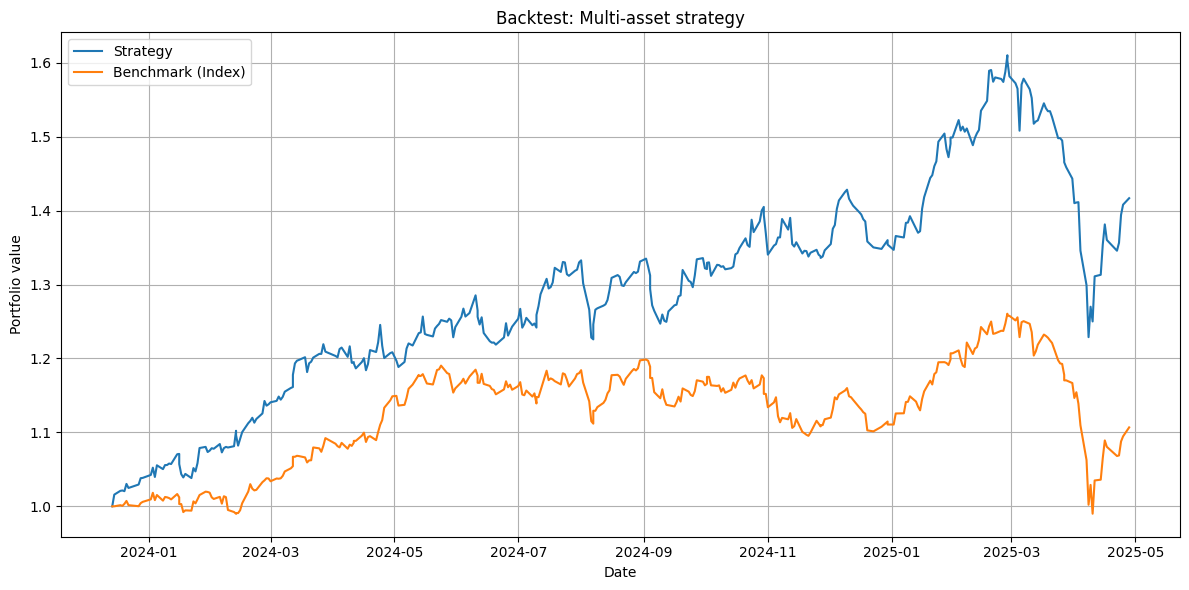

[[0.10000000149011612, 0.0, 8.673617379884035e-16, 0.0, 0.0, 0.15000000596046448, 0.0, 0.0, 0.0, 0.15000000596046448, 0.0, 0.0, 0.0, 0.15000000596046448, 0.0, 5.854691731421724e-17, 0.15000000596046448, 0.0, 0.0, 0.15000000596046448, 0.15000000596046448, 0.0], [0.10000000149011612, 0.0, 0.0, 1.8228149024912543e-16, 0.0, 0.0, 0.0, 0.0, 1.984089975648473e-17, 0.15000000596046448, 0.0, 0.0, 0.0, 0.15000000596046448, 1.85940672581264e-16, 0.0, 0.15000000596046448, 0.0, 0.0, 0.15000000596046448, 0.15000000596046448, 0.15000000596046448], [0.15000000596046448, 0.030314886942505836, 0.15000000596046448, 0.0, 1.4548350043186694e-17, 0.15000000596046448, 0.0, 1.0648935270572506e-16, 1.489256107189369e-16, 0.15000000596046448, 0.0, 0.0, 3.792728160493426e-18, 0.15000000596046448, 0.0, 0.0, 0.0, 0.0, 0.0, 7.875660065755771e-17, 0.15000000596046448, 0.06968510895967484], [0.15000000596046448, 5.140113561294315e-16, 6.170106286900034e-17, 6.754907842569815e-18, 0.0, 0.15000000596046448, 0.0, 1.4204

In [69]:
# Backtest
import importlib
import functions.backtest_multi_asset
importlib.reload(functions.backtest_multi_asset)

from functions.backtest_multi_asset import backtest_multi_asset
df_prices = df_test.copy()

df_index_raw = pd.read_csv("data/MCAP_22_Index_raw.csv", index_col="Date", parse_dates=True)
df_index = df_index_raw.copy()
df_index.columns = ["Close"]
print(df_index.head())

weight_optimizer = PortfolioWeightOptimizer(
    strategy="mean_variance_opt",
    multi_horizon=True,
    risk_aversion=1.0
)

result = backtest_multi_asset(
    ds_test,
    model,
    weight_optimizer,
    df_prices,
    index_df=df_index,
    plot=True,
    trading_cost=0.0,
)

print(result["weights"])
# print(result["values"][-1])
# print(result["benchmark"][-1])
# print(result["values"][-1] / result["benchmark"][-1])
# print(result["dates"][-1])
# print(result["benchmark"][-1], result["benchmark"][0])

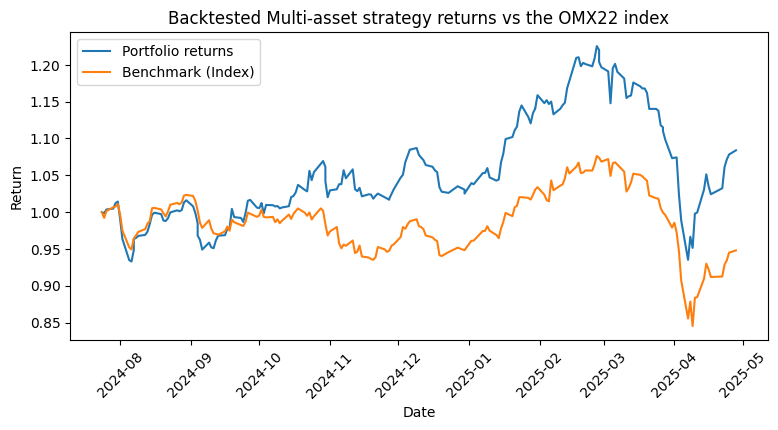

Last portfolio value: 1.0839


In [76]:
portfolio_dates = result["dates"]
portfolio_vals = result["values"]
index_vals = result["benchmark"]


plt.figure(figsize=(9, 4))
plt.plot(portfolio_dates[-200:], np.array(portfolio_vals[-200:])/portfolio_vals[-200], label="Portfolio returns")
if index_vals is not None:
    plt.plot(portfolio_dates[-200:], np.array(index_vals[-200:])/index_vals[-200], label="Benchmark (Index)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Return")
plt.title("Backtested Multi-asset strategy returns vs the OMX22 index")
plt.legend()
plt.show()
print(f"Last portfolio value: {(np.array(portfolio_vals[-200:])/portfolio_vals[-200])[-1]:.4f}")

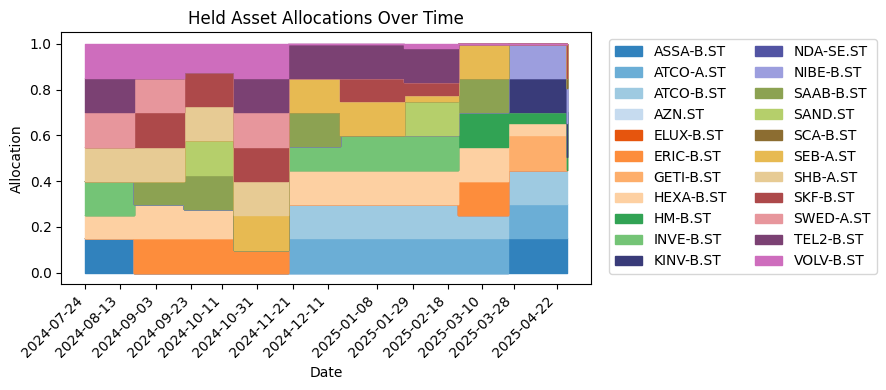

(22, 357)


In [74]:
def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

weights = np.array(result["weights"])  # shape: (num_rebalances, num_assets)
dates = np.array(result["dates"])      # dagliga datum (len = N)

allocations_filled = np.zeros((len(tickers), len(dates)))

rebalance_idxs = np.linspace(0, len(dates)-1, len(weights), dtype=int)
for i in range(len(rebalance_idxs)):
    start = rebalance_idxs[i]
    end = rebalance_idxs[i+1] if i+1 < len(rebalance_idxs) else len(dates)
    allocations_filled[:, start:end] = np.expand_dims(weights[i], axis=1)

plot_allocations(allocations_filled[:, -200:], tickers, dates[-200:])
print(allocations_filled.shape)


In [10]:
import deeplay as dl


gru_dl = dl.RecurrentModel(
    in_features=len(features)*len(tickers),
    hidden_features=[128, 128, 128],
    out_features=len(tickers)*len(horizon),
    rnn_type="GRU",
    dropout=0.2,
)
gru_stacked = dl.Regressor(gru_dl, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=1, accelerator="auto")
trainer.fit(gru_stacked, train_loader, val_loader)

train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | loss          | L1Loss           | 0      | eval 
1 | train_metrics | MetricCollection | 0      | train
2 | val_metrics   | MetricCollection | 0      | train
3 | test_metrics  | MetricCollection | 0      | train
4 | model         | RecurrentModel   | 313 K  | train
5 | optimizer     | Adam             | 0      | train
-----------------------------------------------------------
313 K     Trainable params
0         Non-trainable params
313 K     Total params
1.253     Total estimated model params size (MB)
23        Modules in train mode
1         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 141/141 [00:25<00:00,  5.52it/s, v_num=35, train_loss_step=0.467, val_loss_step=0.793, val_loss_epoch=0.528, train_loss_epoch=0.391]


ValueError: x and y must have same first dimension, but have shapes (50,) and (1,)

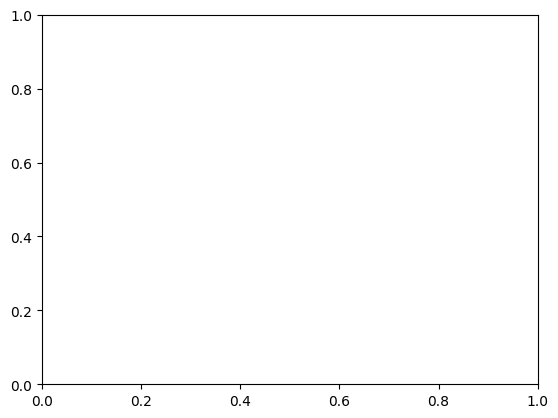

In [11]:
def plot_training(epochs, train_losses, val_losses, benchmark):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.plot([0, epochs - 1], [benchmark, benchmark], ":k", label="Benchmark")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training(50, train_losses, val_losses, benchmark = naive_mae)

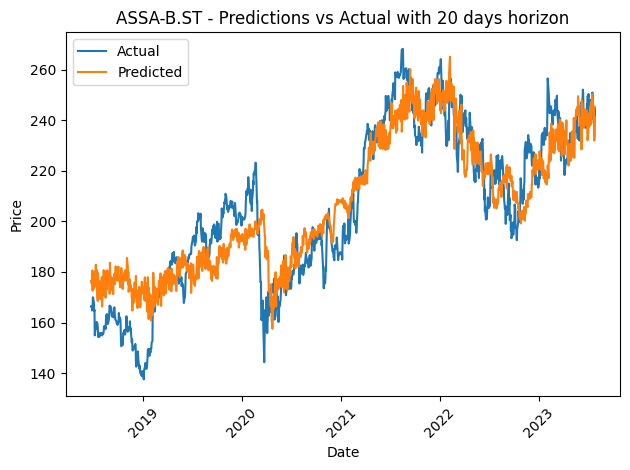

Accuracy: 0.1337
Total accuracy on last horizon: 0.1398
ASSA-B.ST: 0.0572
ATCO-A.ST: 0.1420
ATCO-B.ST: 0.1273
AZN.ST: 0.1662
ELUX-B.ST: 0.1329
ERIC-B.ST: 0.1755
GETI-B.ST: 0.1743
HEXA-B.ST: 0.0901
HM-B.ST: 0.1410
INVE-B.ST: 0.1091
KINV-B.ST: 0.2335
NDA-SE.ST: 0.1256
NIBE-B.ST: 0.2619
SAAB-B.ST: 0.3333
SAND.ST: 0.0753
SCA-B.ST: 0.1330
SEB-A.ST: 0.1008
SHB-A.ST: 0.0828
SKF-B.ST: 0.0879
SWED-A.ST: 0.1362
TEL2-B.ST: 0.0923
VOLV-B.ST: 0.0978
Stock accuracy: 0.0572


In [12]:
# Plot predictions vs actual on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
from functions.plot_predictions import plot_predictions


plot_predictions(
    idx,
    tickers,
    val_loader,
    gru_stacked,
    0,
    20000
)


In [13]:
import deeplay as dl

class CrossAttentionGRUV2(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_hidden_layers, out_dim, dropout, num_heads):
        super().__init__()
        self.gru_model = nn.GRU(in_dim, hidden_dim, num_layers=num_hidden_layers, dropout=dropout, batch_first=True)
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, kdim=in_dim, vdim=in_dim, dropout=0, batch_first=True)
        self.fuse_fc = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.ReLU()
        )
        self.fc = nn.Linear(hidden_dim, out_dim)
        self._stored_attn_weights = None

    def get_attn_weights(self):
        return self._stored_attn_weights

    def forward(self, x):
        gru_out, _ = self.gru_model(x)

        x_proj = x #self.input_proj(x)

        cross_attn_out, cross_attn_weights = self.cross_attn(query=gru_out, key=x_proj, value=x_proj)

        self._stored_attn_weights = cross_attn_weights.detach()
        #print('gru:', gru_out)
        #print('cross attn: ', cross_attn_out)

        combined = torch.cat([gru_out, cross_attn_out], dim=-1)
        fused = self.fuse_fc(combined)
        #print(combined.shape)

        final_step = fused[:, -1, :]
        #print(final_step.shape)

        output = self.fc(final_step)

        return output

In [15]:
cross_attention_gru_model = CrossAttentionGRUV2(in_dim=len(tickers)*len(features), hidden_dim=144, num_hidden_layers=2, out_dim=len(tickers)*len(horizon), dropout=0.2, num_heads=24)

cross_attention_gru_reg = dl.Regressor(cross_attention_gru_model, optimizer=dl.Adam(lr=0.001)).create()

trainer_cross_gru = dl.Trainer(max_epochs=50, accelerator="auto")
trainer_cross_gru.fit(cross_attention_gru_reg, train_loader, val_loader)

train_losses = trainer_cross_gru.history.history["train_loss_epoch"]["value"]
val_losses = trainer_cross_gru.history.history["val_loss_epoch"]["value"][1:]


  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | eval 
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV2 | 354 K  | train
5 | optimizer     | Adam                | 0      | train
--------------------------------------------------------------
354 K     Trainable params
0         Non-trainable params
354 K     Total params
1.420     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode


C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
C:\Users\peogr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 27:  68%|██████▊   | 96/141 [00:24<00:11,  3.91it/s, v_num=37, train_loss_step=0.139, val_loss_step=0.336, val_loss_epoch=0.277, train_loss_epoch=0.115]  

NameError: name 'exit' is not defined

ValueError: x and y must have same first dimension, but have shapes (50,) and (1,)

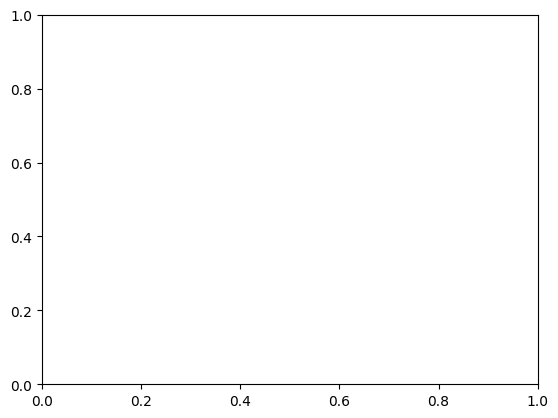

In [16]:
plot_training(50, train_losses, val_losses, naive_mae)

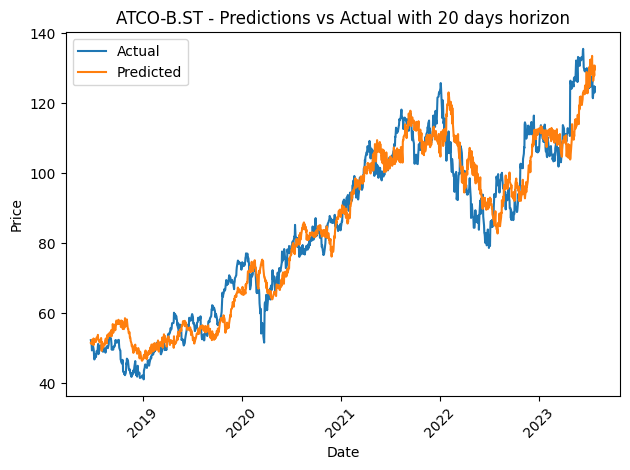

Accuracy: 0.0643
Total accuracy on last horizon: 0.0777
ASSA-B.ST: 0.0530
ATCO-A.ST: 0.0748
ATCO-B.ST: 0.0687
AZN.ST: 0.0633
ELUX-B.ST: 0.0898
ERIC-B.ST: 0.0915
GETI-B.ST: 0.1190
HEXA-B.ST: 0.0732
HM-B.ST: 0.0873
INVE-B.ST: 0.0566
KINV-B.ST: 0.1073
NDA-SE.ST: 0.0691
NIBE-B.ST: 0.1219
SAAB-B.ST: 0.1029
SAND.ST: 0.0703
SCA-B.ST: 0.0634
SEB-A.ST: 0.0689
SHB-A.ST: 0.0568
SKF-B.ST: 0.0760
SWED-A.ST: 0.0752
TEL2-B.ST: 0.0505
VOLV-B.ST: 0.0698
Stock accuracy: 0.0687


In [17]:
# Plot predictions vs actual on test set
import torch
import numpy as np
import matplotlib.pyplot as plt
idx = 2

plot_predictions(
    idx,
    tickers,
    val_loader,
    cross_attention_gru_reg,
    0,
    2000
)

c:\Users\peogr\OneDrive - Chalmers\GitHub\Project-AMLNN\portfolio_optimizers\portfolio_optimizer.py:64: RuntimeWarning: invalid value encountered in log
  log_returns = np.log(1 + portfolio_return)


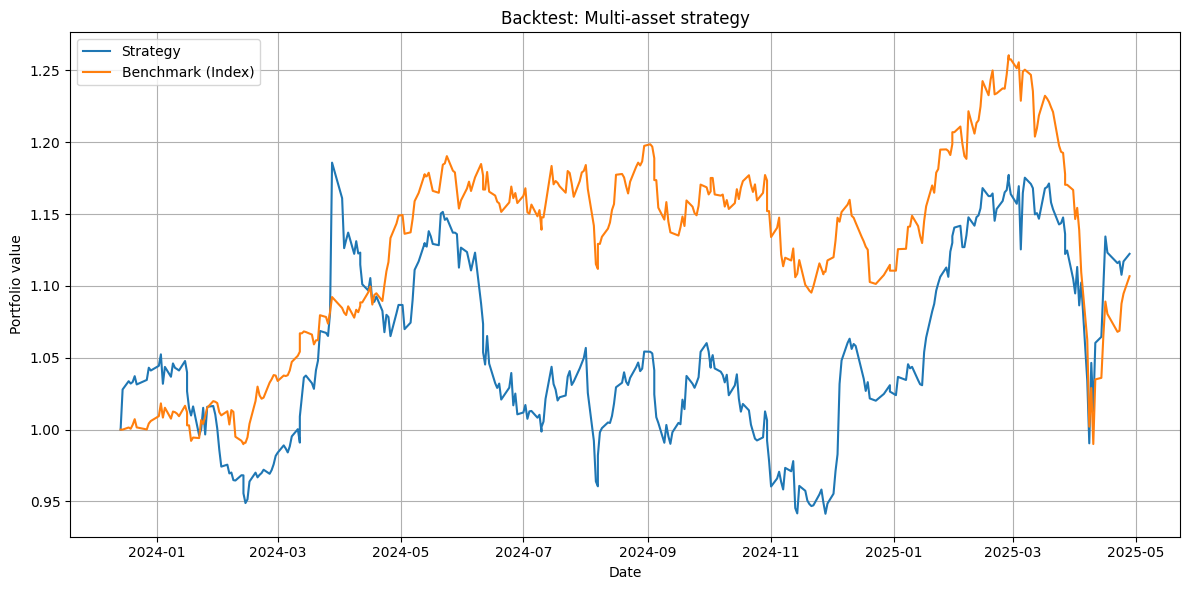

c:\Users\peogr\OneDrive - Chalmers\GitHub\Project-AMLNN\portfolio_optimizers\portfolio_optimizer.py:64: RuntimeWarning: invalid value encountered in log
  log_returns = np.log(1 + portfolio_return)


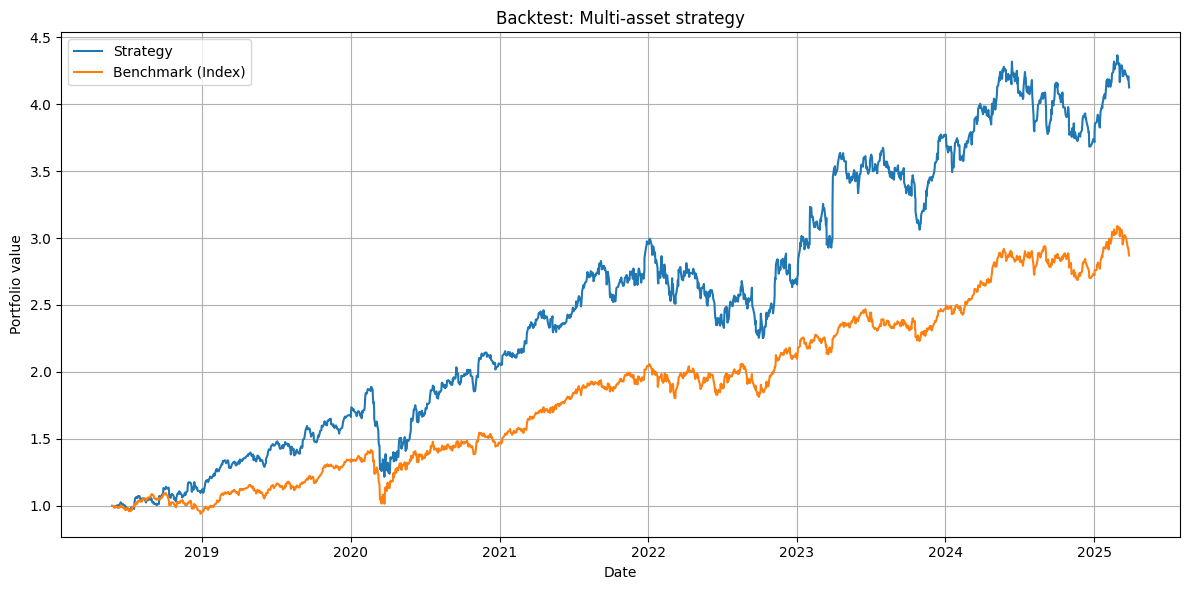

In [23]:
# backtest
weight_optimizer = PortfolioWeightOptimizer(
    strategy="sharpe_opt",
    multi_horizon=True,
    risk_aversion=-0.5
)
result = backtest_multi_asset(
    ds_test,
    cross_attention_gru_reg,
    weight_optimizer,
    df_test,
    index_df=df_index,
    plot=True
)
result = backtest_multi_asset(
    ds_val_test,
    cross_attention_gru_reg,
    weight_optimizer,
    df_val_test,
    index_df=df_index,
    plot=True
)